<a href="https://colab.research.google.com/github/heamy121/mmai/blob/master/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.
2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.
3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?
4. What difficulties did you encounter in obtaining the data?
5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?




(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


In [ ]:
!git clone https://github.com/lil-lab/nlvr.git
%cd nlvr/nlvr


Cloning into 'nlvr'...
remote: Enumerating objects: 82987, done.
remote: Counting objects: 100% (4750/4750), done.
remote: Compressing objects: 100% (4741/4741), done.
remote: Total 82987 (delta 20), reused 4724 (delta 9), pack-reused 78237 (from 1)
Receiving objects: 100% (82987/82987), 226.95 MiB | 41.15 MiB/s, done.
Resolving deltas: 100% (173/173), done.
Updating files: 100% (92281/92281), done.
/content/nlvr/nlvr


In [ ]:
!ls


dev	metrics_images.py	   README.md  train
hidden	metrics_structured_rep.py  test


In [ ]:
!sed -n '1,200p' README.md


# The Cornell Natural Language Visual Reasoning (NLVR) Corpus v1.0
Website: http://lic.nlp.cornell.edu/nlvr/

The corpus and task are described in:
A Corpus of Natural Language for Visual Reasoning.
Alane Suhr, Mike Lewis, James Yeh, and Yoav Artzi.
In *Proceedings of the Conference of the Association for Computational Linguistics (ACL)*, 2017.
Paper: http://yoavartzi.com/pub/slya-acl.2017.pdf  
Supplementary material: http://yoavartzi.com/pub/slya-acl.2017.sup.pdf  

*Update*: As of July 29, 2022, the hidden test set is being released to the public and we will not be updating the leaderboard.

## Structure of repository

There are three subdirectories, one for each split of the data (train,
development, and public test).

In each of the split directories, there are two items:
* **.json** file, containing the labeled sentences, structured representations, and identifiers which can be used to match the example with its six PNG permutations.
* **images** subdirectory, containing the PNG 

Total examples: 12410


FIRST 5 EXAMPLES

Sentence: There is a circle closely touching a corner of a box.
Label: true
Identifier: 1304-0


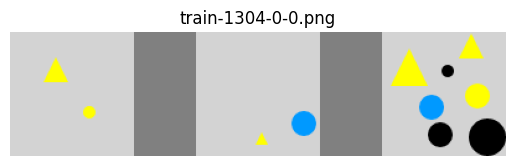

Sentence: There are 2 yellow blocks
Label: true
Identifier: 2170-1


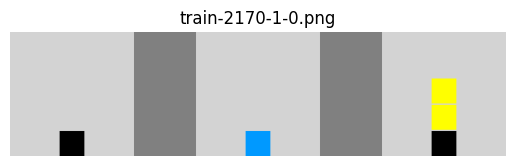

Sentence: There is a box without a blue item.
Label: false
Identifier: 700-2


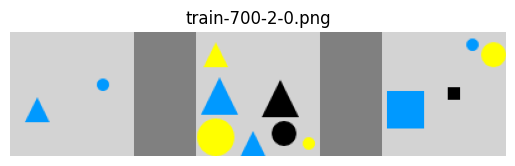

Sentence: there is at least one tower with exactly three blocks
Label: true
Identifier: 3811-0


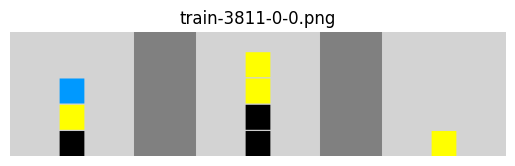

Sentence: There is 1 box with 5 yellow items
Label: true
Identifier: 359-0


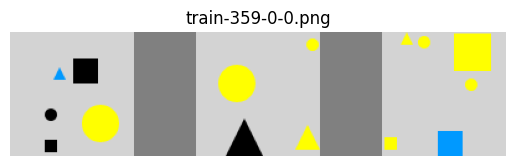



LAST 5 EXAMPLES

Sentence: There is a square closely touching a corner of a box.
Label: false
Identifier: 1418-2


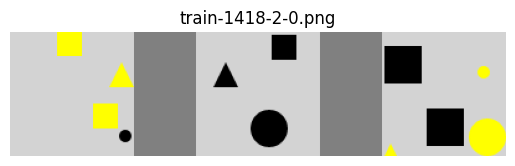

Sentence: There is a square closely touching the bottom of a box.
Label: false
Identifier: 1152-1


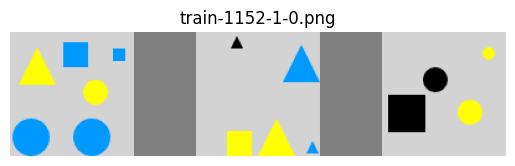

Sentence: There is a tower with a black block above a black block and a blue block at the base
Label: false
Identifier: 3716-2


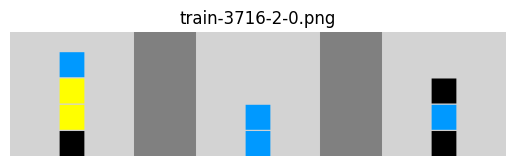

Sentence: There is 1 box with only 1 black circle
Label: true
Identifier: 464-1


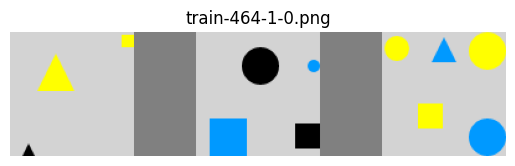

Sentence: There is a box with at least one black square and at least two circles.
Label: false
Identifier: 1030-3


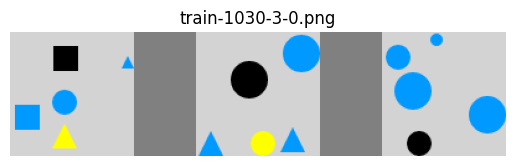

In [ ]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt

# Load data
data = []
with open("train/train.json") as f:
    for line in f:
        data.append(json.loads(line))

print("Total examples:", len(data))


def show_example(ex, split="train"):
    print("="*60)
    print("Sentence:", ex["sentence"])
    print("Label:", ex["label"])
    print("Identifier:", ex["identifier"])

    n_m = ex["identifier"]
    directory = ex["directory"]

    # Show only one permutation (k=0) to keep output manageable
    img_name = f"{split}-{n_m}-0.png"
    img_path = os.path.join(split, "images", directory, img_name)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()


# -------- FIRST 5 --------
print("\n\nFIRST 5 EXAMPLES\n")
for i in range(5):
    show_example(data[i])


# -------- LAST 5 --------
print("\n\nLAST 5 EXAMPLES\n")
for i in range(len(data)-5, len(data)):
    show_example(data[i])


In [ ]:
import json

data = []
with open("train/train.json") as f:
    for line in f:
        data.append(json.loads(line))

print("Number of training examples:", len(data))


Number of training examples: 12410


In [ ]:
import os
from PIL import Image

ex = data[0]
n_m = ex["identifier"]
directory = ex["directory"]

img_path = f"train/images/{directory}/train-{n_m}-0.png"
img = Image.open(img_path)

print("Image size (width, height):", img.size)
print("Image mode:", img.mode)


Image size (width, height): (400, 100)
Image mode: RGBA


In [ ]:
structured_rep = data[0]["structured_rep"]
print(structured_rep)

print("Number of boxes:", len(structured_rep))

for i, box in enumerate(structured_rep):
    print(f"Box {i} number of objects:", len(box))


[[{'y_loc': 21, 'size': 20, 'type': 'triangle', 'x_loc': 27, 'color': 'Yellow'}, {'y_loc': 60, 'size': 10, 'type': 'circle', 'x_loc': 59, 'color': 'Yellow'}], [{'y_loc': 81, 'size': 10, 'type': 'triangle', 'x_loc': 48, 'color': 'Yellow'}, {'y_loc': 64, 'size': 20, 'type': 'circle', 'x_loc': 77, 'color': '#0099ff'}], [{'y_loc': 2, 'size': 20, 'type': 'triangle', 'x_loc': 62, 'color': 'Yellow'}, {'y_loc': 70, 'size': 30, 'type': 'circle', 'x_loc': 70, 'color': 'Black'}, {'y_loc': 51, 'size': 20, 'type': 'circle', 'x_loc': 30, 'color': '#0099ff'}, {'y_loc': 42, 'size': 20, 'type': 'circle', 'x_loc': 67, 'color': 'Yellow'}, {'y_loc': 73, 'size': 20, 'type': 'circle', 'x_loc': 37, 'color': 'Black'}, {'y_loc': 14, 'size': 30, 'type': 'triangle', 'x_loc': 7, 'color': 'Yellow'}, {'y_loc': 27, 'size': 10, 'type': 'circle', 'x_loc': 48, 'color': 'Black'}]]
Number of boxes: 3
Box 0 number of objects: 2
Box 1 number of objects: 2
Box 2 number of objects: 7


In [ ]:
from collections import Counter

labels = [ex["label"] for ex in data]
print("Label distribution:", Counter(labels))


Label distribution: Counter({'true': 6996, 'false': 5414})


(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use different distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [ ]:
# Packages (feel free to include more if needed)!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

# Data Distribution

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE


def normalize_color(color):
    color = color.lower()

    if color == "#0099ff":
        return "blue"
    if color == "yellow":
        return "yellow"
    if color == "black":
        return "black"

    return color  # fallback


def encode_structured_rep(ex):
    type_vocab = ["square", "circle", "triangle"]
    color_vocab = ["blue", "yellow", "black"]

    type_counts = dict.fromkeys(type_vocab, 0)
    color_counts = dict.fromkeys(color_vocab, 0)

    sizes = []
    x_coords = []
    y_coords = []

    for box in ex["structured_rep"]:
        for obj in box:
            obj_type = obj["type"].lower()
            obj_color = normalize_color(obj["color"])

            if obj_type in type_counts:
                type_counts[obj_type] += 1

            if obj_color in color_counts:
                color_counts[obj_color] += 1

            sizes.append(obj["size"])
            x_coords.append(obj["x_loc"])
            y_coords.append(obj["y_loc"])

    # Aggregate spatial & size statistics
    size_mean = np.mean(sizes)
    size_std = np.std(sizes)
    x_mean = np.mean(x_coords)
    y_mean = np.mean(y_coords)

    vector = (
        list(type_counts.values()) +
        list(color_counts.values()) +
        [size_mean, size_std, x_mean, y_mean]
    )

    return np.array(vector)

def visualize_nlvr_distribution(data,
                                 num_components=2,
                                 perplexity=30,
                                 num_iterations=500):
    """
    Visualizes NLVR structured_rep distribution using t-SNE.

    Args:
        data: list of NLVR examples (parsed JSON)
    """

    # Encode structured representations
    vectors = np.array([encode_structured_rep(ex) for ex in data])

    # Encode labels
    labels = np.array([1 if ex["label"] == "true" else 0 for ex in data])

    # Run t-SNE
    tsne = TSNE(n_components=num_components,
                perplexity=perplexity,
                n_iter=num_iterations,
                random_state=42)

    tsne_data = tsne.fit_transform(vectors)

    # Plot
    plt.figure(figsize=(8, 6))

    false_points = tsne_data[labels == 0]
    true_points = tsne_data[labels == 1]


    plt.scatter(false_points[:, 0],
                false_points[:, 1],
                color="blue",
                alpha=0.6,
                label="False")

    plt.scatter(true_points[:, 0],
                true_points[:, 1],
                color="red",
                alpha=0.6,
                label="True")

    plt.title("t-SNE Visualization of NLVR Structured Representations")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


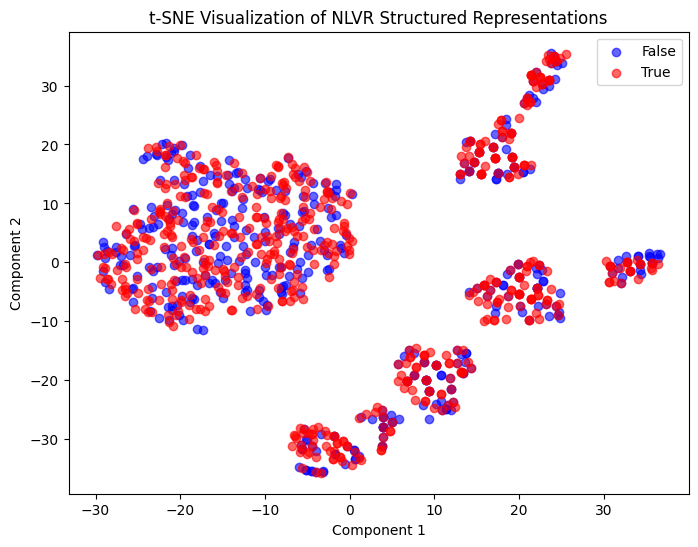

In [ ]:
visualize_nlvr_distribution(data[:1000])  # Use subset if large


In [ ]:
import collections
import matplotlib.pyplot as plt
import numpy as np

def plot_all_property_distributions(data):
    """
    Plots distributions of:
    - type
    - color
    - size
    - x_loc
    - y_loc
    """

    types = []
    colors = []
    sizes = []
    x_locs = []
    y_locs = []

    for example in data:

        # Handle wrapped dictionary case
        if isinstance(example, dict):
            structured = example["structured_rep"]
        else:
            structured = example

        for box in structured:
            for obj in box:
                types.append(obj["type"])
                colors.append(obj["color"])
                sizes.append(obj["size"])
                x_locs.append(obj["x_loc"])
                y_locs.append(obj["y_loc"])

    # ----- Plot categorical distributions -----
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # Type distribution
    type_counts = collections.Counter(types)
    axes[0,0].bar(type_counts.keys(), type_counts.values())
    axes[0,0].set_title("Type Distribution")

    # Color distribution
    color_counts = collections.Counter(colors)
    axes[0,1].bar(color_counts.keys(), color_counts.values())
    axes[0,1].set_title("Color Distribution")
    axes[0,1].tick_params(axis='x', rotation=45)

    # Size distribution
    axes[0,2].hist(sizes, bins=10)
    axes[0,2].set_title("Size Distribution")

    # X location distribution
    axes[1,0].hist(x_locs, bins=10)
    axes[1,0].set_title("X Location Distribution")

    # Y location distribution
    axes[1,1].hist(y_locs, bins=10)
    axes[1,1].set_title("Y Location Distribution")

    # Remove empty subplot
    fig.delaxes(axes[1,2])

    plt.tight_layout()
    plt.show()


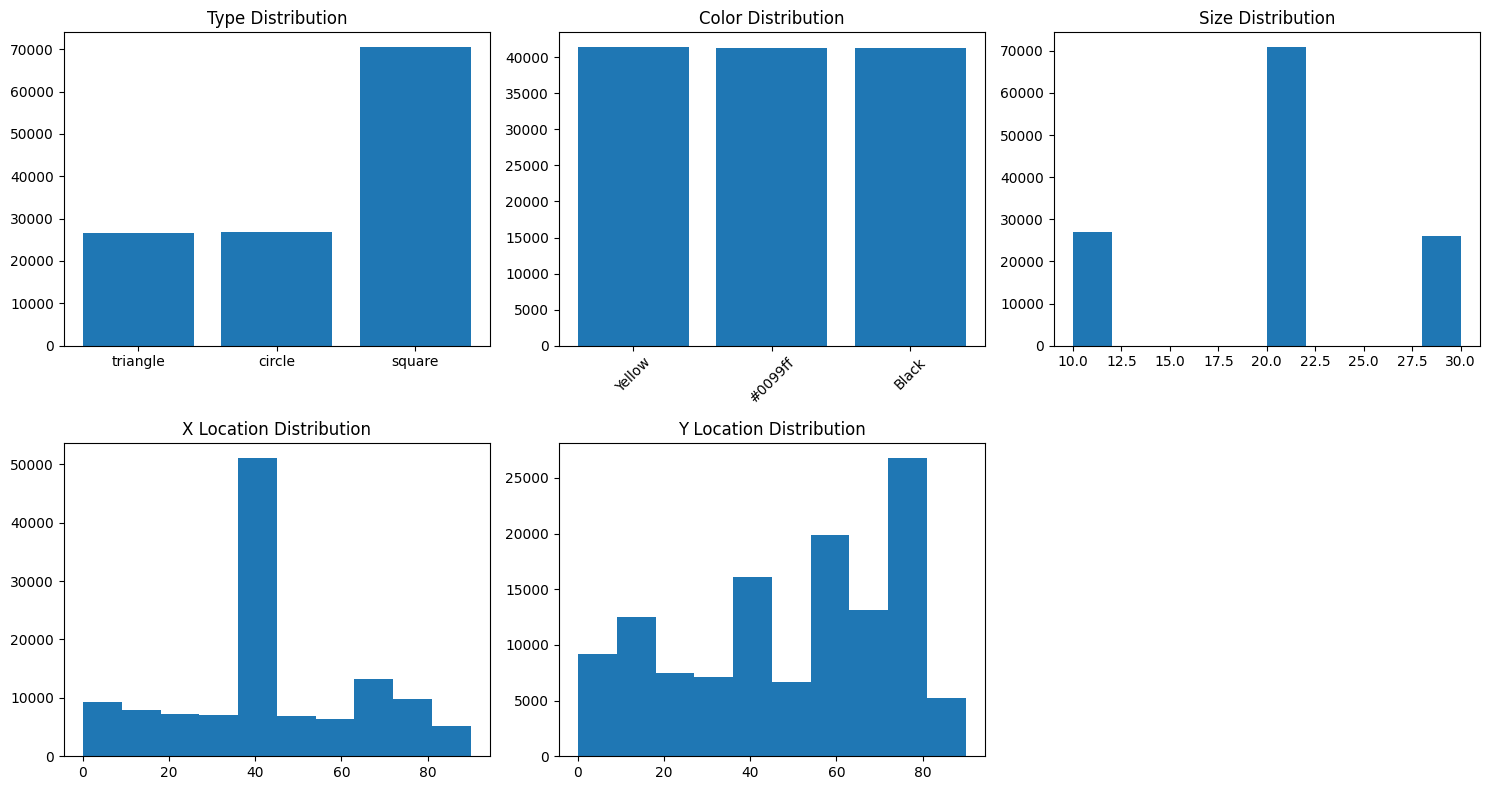

In [ ]:
plot_all_property_distributions(data)

# Samples

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

def visualize_samples(data, split="train", num_samples=5):
    """
    Visualizes random NLVR examples with sentence, label, and image.

    Args:
        data: list of NLVR examples (parsed JSON)
        split: dataset split ("train", "dev", "test")
        num_samples: number of examples to visualize
    """

    if num_samples > len(data):
        print(f"Error: num_samples ({num_samples}) exceeds dataset size ({len(data)})")
        return

    samples = random.sample(data, num_samples)

    for ex in samples:
        print("="*60)
        print("Sentence:", ex["sentence"])
        print("Label:", ex["label"])
        print("Identifier:", ex["identifier"])

        directory = ex["directory"]
        identifier = ex["identifier"]

        # show first permutation only (k=0)
        img_path = f"{split}/images/{directory}/{split}-{identifier}-0.png"

        if os.path.exists(img_path):
            img = Image.open(img_path)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{split}-{identifier}-0.png")
            plt.show()
        else:
            print("Image not found:", img_path)


Sentence: There is a box with a blue square and at least two black items including circle.
Label: false
Identifier: 1366-3


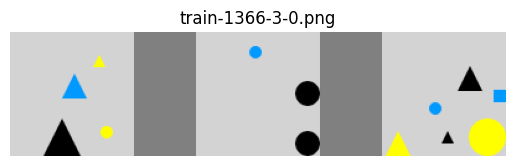

Sentence: There is only one blue block as the top of a tower.
Label: true
Identifier: 3192-1


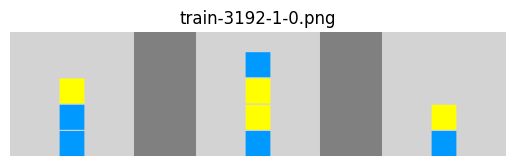

Sentence: There is a tower with a yellow block at the top
Label: false
Identifier: 2451-2


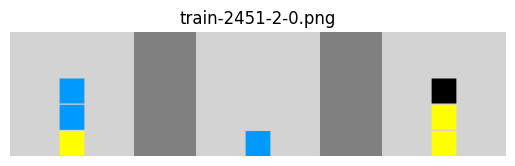

Sentence: There is a box with a blue triangle and two black circles.
Label: false
Identifier: 1232-2


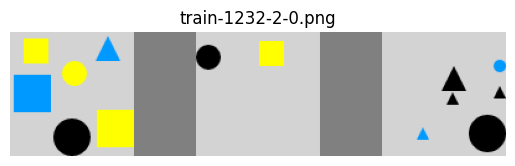

Sentence: There is a square closely touching right wall of a box.
Label: false
Identifier: 1227-2


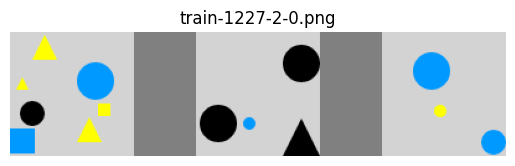

In [ ]:
visualize_samples(data)

# Input Distribution

In [ ]:
def visualize_input_distribution(data, subset_size=1000):
    """
    Visualizes distribution of NLVR structured representations using t-SNE.
    """

    import random

    if subset_size > len(data):
        subset_size = len(data)

    subset = random.sample(data, subset_size)

    visualize_nlvr_distribution(subset)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


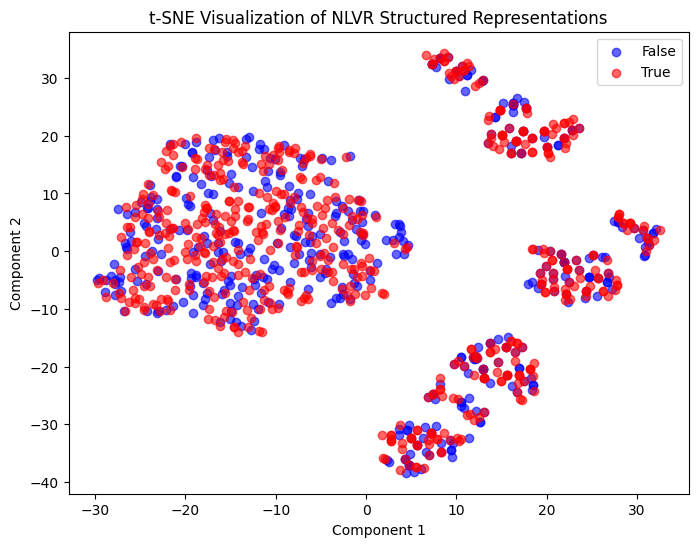

In [ ]:
visualize_input_distribution(data)

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [ ]:
import torch
import torch.nn.functional as F

def structured_loss(
    pred_counts,
    true_counts,
    pred_type_logits,
    true_type_labels,
    pred_color_logits,
    true_color_labels,
    pred_size,
    true_size,
    pred_x,
    true_x,
    pred_y,
    true_y,
    lambda_count=1.0,
    lambda_cat=1.0,
    lambda_num=0.1
):

    # Count loss
    count_loss = F.cross_entropy(pred_counts, true_counts)

    # Categorical losses
    type_loss = F.cross_entropy(pred_type_logits, true_type_labels)
    color_loss = F.cross_entropy(pred_color_logits, true_color_labels)
    categorical_loss = type_loss + color_loss

    # Numeric losses
    size_loss = F.mse_loss(pred_size, true_size)
    x_loss = F.mse_loss(pred_x, true_x)
    y_loss = F.mse_loss(pred_y, true_y)
    numeric_loss = size_loss + x_loss + y_loss

    total_loss = (
        lambda_count * count_loss
        + lambda_cat * categorical_loss
        + lambda_num * numeric_loss
    )

    return total_loss


In [ ]:
import numpy as np

def binary_cross_entropy(pred_probs, targets):
    """
    pred_probs: np.array of shape (N,) with values in (0,1)
    targets: np.array of shape (N,) with 0 or 1
    """

    epsilon = 1e-12  # for numerical stability

    loss = -np.mean(
        targets * np.log(pred_probs + epsilon) +
        (1 - targets) * np.log(1 - pred_probs + epsilon)
    )

    return loss


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. This is when you prompt the model in specific ways to guarantee a specific output. Provide prompts that would be able to guarantee the right output based on the data.

Scenario 1: You have a dataset of reviews from restaurants, when you see this review: "This place stinks, the service was awful and the food was not cooked. I will never come back here!" Provide a prompt that would have the model return the sentiment of the review, which is negative.

Read this restaurant review: "This place stinks, the service was awful and the food was not cooked. I will never come back here!" Tell me if the review is positive or negative, and provide reasoning.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Each face in the dataset can either be angry, sad, or happy. For each face, indicate which of the three emotions is expressed by the face.

Scenario 3: A dataset of novels, with the following paragraph: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

Read this paragraph from the novel: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."  Respond with who is the subject? Where is the subject going? And what is the activity the subject will do at the destination?


**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [ ]:
import os
print(os.listdir("/content/"))



['.config', 'BlackpinkDataset.zip', 'sample_data']


In [ ]:
import os
from PIL import Image
import zipfile

zip_path = "/content/BlackpinkDataset.zip"
extract_path = "/content/BlackpinkDataset"

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

for root, dirs, files in os.walk(extract_path):
    if "__MACOSX" in root:
        continue

    for file in files:
        if file.startswith("._"):
            continue

        if file.lower().endswith(".webp"):
            webp_path = os.path.join(root, file)
            jpg_path = os.path.join(root, file.rsplit(".", 1)[0] + ".jpg")

            with Image.open(webp_path) as img:
                img.convert("RGB").save(jpg_path, "JPEG")

            os.remove(webp_path)

print("All WEBP images converted to JPG, macOS artifacts skipped!")


Files extracted to: /content/BlackpinkDataset
All WEBP images converted to JPG, macOS artifacts skipped!


In [ ]:
import os

print(os.listdir("/content/BlackpinkDataset"))

print(os.listdir("/content/BlackpinkDataset/BlackpinkDataset"))


['__MACOSX', 'BlackpinkDataset']
['Jennie8.jpg', 'Jennie7.jpg', 'Lisa5.jpeg', 'Lisa2.jpg', 'Jisoo5.jpeg', 'Lisa1.jpg', 'Jennie3.jpg', 'Jennie9.jpeg', 'Rose4.jpeg', 'Rose7.jpeg', 'Jisoo7.jpg', 'Jisoo4.jpg', 'Jennie2.jpg', 'Lisa8.jpg', 'Jisoo6.jpeg', 'Lisa7.jpg', 'Rose1.jpg', 'Lisa9.jpg', 'Rose9.jpeg', 'Jennie0.jpeg', 'Rose5.jpg', 'Rose0.jpeg', 'Jisoo8.jpg', 'Rose2.jpg', 'Jisoo2.jpg', 'Lisa0.jpg', 'Jisoo9.jpeg', 'Rose3.jpg', 'Lisa4.jpg', 'Jennie1.jpg', 'Rose6.jpeg', 'Rose8.jpeg', 'Jisoo0.jpg', 'Jisoo1.jpg', 'Lisa3.jpg', 'Jennie6.jpg', 'Jennie5.jpg', 'Jisoo3.jpg', 'Lisa6.jpg', 'Jennie4.jpg']


In [ ]:
import os
from PIL import Image
import re

image_dir = "/content/BlackpinkDataset/BlackpinkDataset"
data = []

for file in os.listdir(image_dir):
    if file.startswith("._") or file.startswith("__MACOSX"):
        continue

    ext = file.lower().split(".")[-1]
    if ext in ["jpg", "jpeg", "png", "webp", "avif"]:
        file_path = os.path.join(image_dir, file)

        if ext in ["webp", "avif"]:
            jpg_path = os.path.join(image_dir, os.path.splitext(file)[0] + ".jpg")
            with Image.open(file_path) as img:
                img.convert("RGB").save(jpg_path, "JPEG")
            os.remove(file_path)
            file_path = jpg_path

        match = re.match(r"[A-Za-z]+", file)
        if match:
            label = match.group().lower()
            data.append((file_path, label))
        else:
            print(f"Skipping file (no letters at start): {file_path}")

print("Number of images found:", len(data))
labels = sorted(list(set([d[1] for d in data])))
label_map = {label: i for i, label in enumerate(labels)}
print("Label mapping:", label_map)


Number of images found: 40
Label mapping: {'jennie': 0, 'jisoo': 1, 'lisa': 2, 'rose': 3}


In [ ]:
!pip install facenet-pytorch --quiet


Using device: cuda
Label mapping: {'jennie': 0, 'jisoo': 1, 'lisa': 2, 'rose': 3}
Train size: 32 Val size: 8
Extracting augmented training embeddings...
Extracting validation embeddings...
Train embeddings shape: (157, 512)
Val embeddings shape: (8, 512)

=== TRAIN METRICS ===
              precision    recall  f1-score   support

      jennie       1.00      1.00      1.00        40
       jisoo       1.00      1.00      1.00        38
        lisa       1.00      1.00      1.00        40
        rose       1.00      1.00      1.00        39

    accuracy                           1.00       157
   macro avg       1.00      1.00      1.00       157
weighted avg       1.00      1.00      1.00       157


=== VALIDATION METRICS ===
              precision    recall  f1-score   support

      jennie       1.00      1.00      1.00         2
       jisoo       1.00      1.00      1.00         2
        lisa       1.00      1.00      1.00         2
        rose       1.00      1.00      1.0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


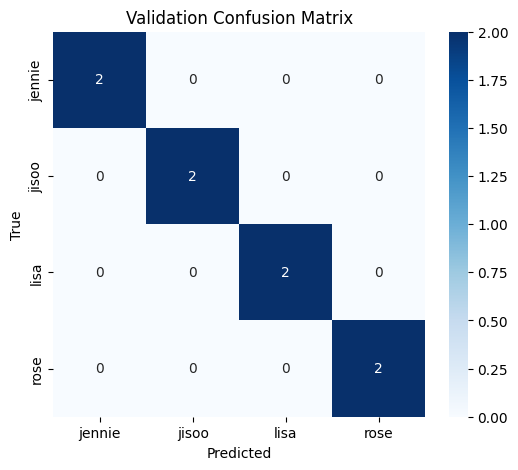

In [ ]:

import os
import re
import torch
import numpy as np
from PIL import Image
from facenet_pytorch import InceptionResnetV1, MTCNN
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import torchvision.transforms as T
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

image_dir = "/content/BlackpinkDataset/BlackpinkDataset"

data = []
for img in os.listdir(image_dir):
    if img.lower().endswith((".jpg", ".png", ".jpeg")):
        label = re.match(r"[A-Za-z]+", img).group().lower()
        data.append((img, label))

labels = sorted(list(set([d[1] for d in data])))
label_map = {label:i for i,label in enumerate(labels)}
print("Label mapping:", label_map)

data = [(img, label_map[label]) for img, label in data]

train_data, val_data = train_test_split(data, test_size=0.2, stratify=[l for _,l in data], random_state=42)
print("Train size:", len(train_data), "Val size:", len(val_data))

# =========================
# FACE DETECTION + AUGMENTATION
# =========================
mtcnn = MTCNN(image_size=160, margin=0, device=device)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

train_aug = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)
])

val_aug = T.Compose([])  # no augmentation for validation

def extract_embedding(img_path, augment=None):
    img = Image.open(img_path).convert('RGB')
    if augment:
        img = augment(img)
    face = mtcnn(img)
    if face is None:
        return None
    face = face.unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = resnet(face)
    return embedding.cpu().numpy()[0]

def build_embeddings_augmented(data_list, augment=None, repeats=5):
    embeddings = []
    labels_list = []
    for img_name, label in data_list:
        path = os.path.join(image_dir, img_name)
        for _ in range(repeats):
            emb = extract_embedding(path, augment)
            if emb is not None:
                embeddings.append(emb)
                labels_list.append(label)
    return np.array(embeddings), np.array(labels_list)

print("Extracting augmented training embeddings...")
X_train, y_train = build_embeddings_augmented(train_data, augment=train_aug, repeats=5)

print("Extracting validation embeddings...")
X_val, y_val = build_embeddings_augmented(val_data, augment=val_aug, repeats=1)

print("Train embeddings shape:", X_train.shape)
print("Val embeddings shape:", X_val.shape)

# =========================
# 5. TRAIN CLASSIFIER
# =========================
clf = LogisticRegression(max_iter=1000, multi_class='multinomial')
clf.fit(X_train, y_train)

# =========================
# 6. EVALUATION
# =========================
y_pred_train = clf.predict(X_train)
y_pred_val = clf.predict(X_val)

print("\n=== TRAIN METRICS ===")
print(classification_report(y_train, y_pred_train, target_names=labels, zero_division=0))

print("\n=== VALIDATION METRICS ===")
print(classification_report(y_val, y_pred_val, target_names=labels, zero_division=0))

cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix")
plt.show()


(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!